# Results PnL + CLV Monitor

Purpose: track bankroll, ROI, and CLV trajectory over time for the active bet stream.

Use this for progress tracking, not for calibration root cause.

Compact bankroll and CLV monitoring notebook for ongoing betting progress.

In [1]:
from pathlib import Path
import sys
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import HTML, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "production").exists() and (candidate / "src" / "Python").exists():
        ROOT = candidate
        break

sys.path.insert(0, str(ROOT / "src"))
from Python.exit_anomalies import apply_exit_anomaly_overrides
from Python.notebook_analysis_utils import (
    has_over_clv_red_flag,
    keep_best_available_lines,
    side_clv_roi_health,
)
from Python.odds_ledger import load_ledger


def show_table(df: pl.DataFrame, max_rows: int = 30, height: int = 420):
    pdf = df.head(max_rows).to_pandas().round(3)
    display(pdf)
    if df.height > max_rows:
        print(f"showing first {max_rows} of {df.height} rows")


# Add/adjust process-change markers here as your workflow evolves.
PROCESS_CHANGES = [
    {"date": "2026-08-03", "label": "Platt calibration on"},
    {"date": "2026-08-12", "label": "Profile policy sync"},
]


def add_process_lines(ax):
    ymin, ymax = ax.get_ylim()
    yspan = ymax - ymin if ymax != ymin else 1.0
    for i, evt in enumerate(PROCESS_CHANGES):
        d = evt.get("date")
        if d is None:
            continue
        ax.axvline(d, color="gray", linestyle="--", linewidth=1, alpha=0.5)
        ax.text(
            d,
            ymax - (0.05 + 0.08 * (i % 2)) * yspan,
            evt.get("label", d),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color="gray",
        )


EXIT_ANOMALY_PATH = ROOT / "production" / "ops" / "exit_anomaly_overrides.csv"
EXCLUDE_EXIT_ANOMALIES_FOR_PROCESS = True

led = load_ledger()
settled_raw = led.filter((pl.col("status") == "settled") & (pl.col("stake").cast(pl.Float64).fill_null(0.0) > 0)) if not led.is_empty() else led
settled_raw = settled_raw.with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("game_date")) if "game_date" in settled_raw.columns else settled_raw
settled_all = keep_best_available_lines(settled_raw)
settled_tagged = apply_exit_anomaly_overrides(settled_all, path=EXIT_ANOMALY_PATH)
settled_core = settled_tagged.filter(~pl.col("exit_anomaly_flag")) if "exit_anomaly_flag" in settled_tagged.columns else settled_tagged
settled = settled_core if EXCLUDE_EXIT_ANOMALIES_FOR_PROCESS else settled_tagged

print(
    f"settled bets (raw): {settled_raw.height} | best-line settled: {settled_all.height} | "
    f"anomaly-tagged: {int(settled_tagged.filter(pl.col('exit_anomaly_flag')).height) if 'exit_anomaly_flag' in settled_tagged.columns else 0} | "
    f"analysis_view={'core_ex_anomaly' if EXCLUDE_EXIT_ANOMALIES_FOR_PROCESS else 'all_rows'} n={settled.height}"
)

if "exit_anomaly_flag" in settled_tagged.columns:
    all_health = side_clv_roi_health(settled_tagged)
    core_health = side_clv_roi_health(settled_core)
    all_health = all_health.with_columns(pl.lit("all_rows").alias("scope")) if not all_health.is_empty() else all_health
    core_health = core_health.with_columns(pl.lit("core_ex_anomaly").alias("scope")) if not core_health.is_empty() else core_health
    if not all_health.is_empty() or not core_health.is_empty():
        health_compare = pl.concat([all_health, core_health], how="vertical_relaxed")
        print("side CLV/ROI health: all vs anomaly-filtered")
        show_table(health_compare.select([c for c in ["scope", "side", "n", "stake", "pnl", "roi", "mean_clv_pp"] if c in health_compare.columns]), max_rows=20)

side_health = side_clv_roi_health(settled)
if side_health.height:
    print("side CLV/ROI health (active analysis view)")
    show_table(side_health, max_rows=10)
    if has_over_clv_red_flag(side_health):
        print("RED FLAG: over mean_clv_pp <= 0 (or missing).")

settled bets (raw): 538 | best-line settled: 342 | anomaly-tagged: 2 | analysis_view=core_ex_anomaly n=340
side CLV/ROI health: all vs anomaly-filtered


,scope,side,n,stake,pnl,roi,mean_clv_pp
0,all_rows,over,183,12321.027,-1535.029,-0.125,0.007
1,all_rows,under,159,11980.254,1704.775,0.142,0.006
2,core_ex_anomaly,over,182,12260.696,-1474.698,-0.120,0.007
3,core_ex_anomaly,under,158,11851.664,1591.977,0.134,0.006


side CLV/ROI health (active analysis view)


,side,n,stake,pnl,roi,mean_clv_pp
0,over,182,12260.696,-1474.698,-0.120,0.007
1,under,158,11851.664,1591.977,0.134,0.006


In [2]:
if settled.is_empty():
    print("No settled bets available.")
else:
    by_day = (
        settled.group_by("game_date")
        .agg(
            pl.len().alias("n_bets"),
            pl.col("pnl").cast(pl.Float64).sum().alias("pnl_day"),
            (pl.col("clv_pp") > 0).mean().alias("beat_clv_rate"),
            pl.col("clv_pp").drop_nulls().len().alias("n_clv"),
            (pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum().alias("expected_pnl_day"),
            pl.col("stake").cast(pl.Float64).sum().alias("stake_day"),
        )
        .sort("game_date")
        .with_columns([
            pl.col("pnl_day").cum_sum().alias("pnl_cum"),
            pl.col("expected_pnl_day").cum_sum().alias("expected_pnl_cum"),
            (pl.col("pnl_day") / pl.col("stake_day")).alias("roi_day"),
            (pl.col("expected_pnl_day") / pl.col("stake_day")).alias("expected_roi_day"),
        ])
    )
    show_table(by_day.tail(20))

,game_date,n_bets,pnl_day,beat_clv_rate,n_clv,expected_pnl_day,stake_day,pnl_cum,expected_pnl_cum,roi_day,expected_roi_day
0,2026-08-20,3,-48.449,0.500,2,33.414,176.720,-2.183,2544.209,-0.274,0.189
1,2026-08-21,12,-98.693,0.333,12,102.956,725.135,-100.876,2647.165,-0.136,0.142
2,2026-08-22,6,18.096,NaN,0,84.354,376.630,-82.780,2731.519,0.048,0.224
3,2026-08-23,5,-94.253,NaN,0,71.248,284.190,-177.034,2802.767,-0.332,0.251
4,2026-08-25,12,276.972,NaN,0,116.869,791.218,99.939,2919.636,0.350,0.148
5,2026-08-26,12,-282.472,0.583,12,137.437,851.145,-182.534,3057.073,-0.332,0.161
6,2026-08-27,5,205.886,0.000,1,96.852,431.536,23.353,3153.925,0.477,0.224
7,2026-08-28,4,45.948,NaN,0,37.599,204.300,69.300,3191.524,0.225,0.184
8,2026-08-29,16,-255.531,0.000,1,219.520,1189.272,-186.231,3411.044,-0.215,0.185
9,2026-08-30,9,-72.562,0.333,6,85.808,598.316,-258.793,3496.852,-0.121,0.143


In [3]:
if settled.is_empty():
    print("No side split to report.")
else:
    side = (
        settled.group_by("side")
        .agg(
            pl.len().alias("n_bets"),
            pl.col("pnl").cast(pl.Float64).sum().alias("pnl"),
            pl.col("result").eq("win").mean().alias("win_rate"),
            (pl.col("clv_pp") > 0).mean().alias("beat_clv_rate"),
            pl.col("clv_pp").drop_nulls().len().alias("n_clv"),
            (pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum().alias("expected_pnl"),
            ((pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum() / pl.col("stake").cast(pl.Float64).sum()).alias("expected_roi"),
        )
        .sort("n_bets", descending=True)
    )
    show_table(side)

,side,n_bets,pnl,win_rate,beat_clv_rate,n_clv,expected_pnl,expected_roi
0,over,182,-1474.698,0.423,0.580,112,2199.006,0.179
1,under,158,1591.977,0.576,0.489,90,2355.708,0.199


daily CLV hit-rate + expected value


,game_date,n_bets,beat_clv_rate,pnl_day,expected_pnl_day,roi_day,expected_roi_day,pnl_cum,expected_pnl_cum
0,2026-08-11,11,0.727,110.651,188.710,0.134,0.229,109.545,1340.534
1,2026-08-12,8,0.875,-195.127,75.564,-0.436,0.169,-85.581,1416.097
2,2026-08-13,1,1.000,99.826,23.475,1.120,0.263,14.245,1439.572
3,2026-08-15,6,0.667,-324.866,169.312,-0.566,0.295,-310.622,1608.885
4,2026-08-17,8,0.625,1.430,100.241,0.003,0.193,-309.192,1709.125
5,2026-08-18,5,0.600,-91.866,37.416,-0.379,0.154,-401.058,1746.541
6,2026-08-19,6,0.500,220.913,74.145,0.571,0.192,-180.145,1820.686
7,2026-08-20,2,0.500,6.311,24.729,0.052,0.203,-173.834,1845.415
8,2026-08-21,12,0.333,-98.693,102.956,-0.136,0.142,-272.527,1948.370
9,2026-08-26,12,0.583,-282.472,137.437,-0.332,0.161,-554.999,2085.807



overall CLV/EV summary


,n_bets,mean_daily_beat_clv_rate,pnl_total,expected_pnl_total,roi_total,expected_roi_total
0,202,0.539,-168.358,2717.588,-0.012,0.188


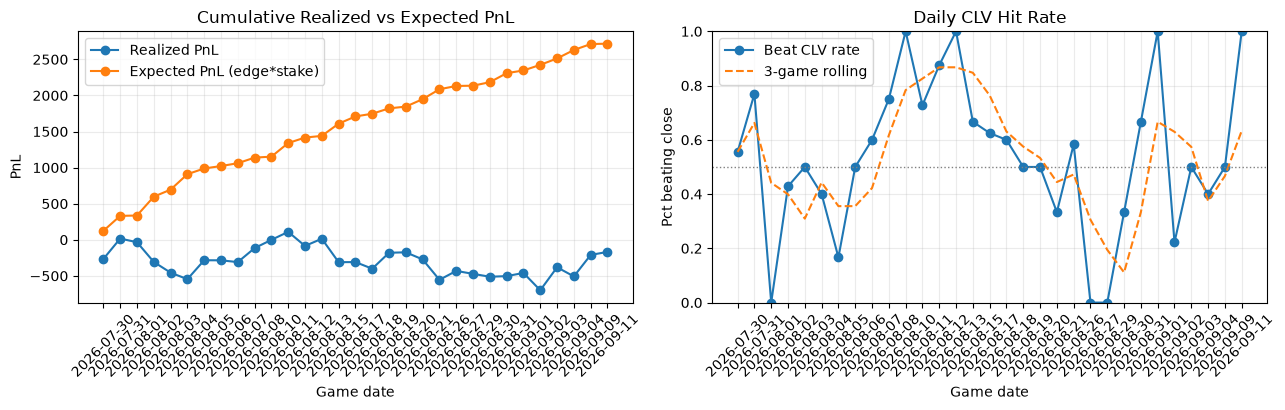

In [4]:
if settled.is_empty():
    print("No CLV/EV diagnostics to report.")
else:
    clv_src = settled.filter(pl.col("clv_pp").is_not_null())
    if clv_src.is_empty():
        print("No non-null CLV rows yet.")
    else:
        # Expected PnL proxy: edge * stake per bet, aggregated by day.
        daily = (
            clv_src.group_by("game_date")
            .agg(
                pl.len().alias("n_bets"),
                (pl.col("clv_pp") > 0).mean().alias("beat_clv_rate"),
                pl.col("pnl").cast(pl.Float64).sum().alias("pnl_day"),
                (pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum().alias("expected_pnl_day"),
                pl.col("stake").cast(pl.Float64).sum().alias("stake_day"),
            )
            .sort("game_date")
            .with_columns([
                (pl.col("pnl_day") / pl.col("stake_day")).alias("roi_day"),
                (pl.col("expected_pnl_day") / pl.col("stake_day")).alias("expected_roi_day"),
                pl.col("pnl_day").cum_sum().alias("pnl_cum"),
                pl.col("expected_pnl_day").cum_sum().alias("expected_pnl_cum"),
            ])
        )

        print("daily CLV hit-rate + expected value")
        show_table(
            daily.select([
                "game_date", "n_bets", "beat_clv_rate", "pnl_day", "expected_pnl_day", "roi_day", "expected_roi_day", "pnl_cum", "expected_pnl_cum"
            ]).tail(20)
        )

        overall = daily.select([
            pl.col("n_bets").sum().alias("n_bets"),
            pl.col("beat_clv_rate").mean().alias("mean_daily_beat_clv_rate"),
            pl.col("pnl_day").sum().alias("pnl_total"),
            pl.col("expected_pnl_day").sum().alias("expected_pnl_total"),
            (pl.col("pnl_day").sum() / pl.col("stake_day").sum()).alias("roi_total"),
            (pl.col("expected_pnl_day").sum() / pl.col("stake_day").sum()).alias("expected_roi_total"),
        ])
        print("\noverall CLV/EV summary")
        show_table(overall)

        pdf = daily.to_pandas()
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

        axes[0].plot(pdf["game_date"], pdf["pnl_cum"], marker="o", label="Realized PnL")
        axes[0].plot(pdf["game_date"], pdf["expected_pnl_cum"], marker="o", label="Expected PnL (edge*stake)")
        axes[0].set_title("Cumulative Realized vs Expected PnL")
        axes[0].set_xlabel("Game date")
        axes[0].set_ylabel("PnL")
        axes[0].tick_params(axis="x", rotation=45)
        axes[0].legend()
        axes[0].grid(alpha=0.25)

        axes[1].plot(pdf["game_date"], pdf["beat_clv_rate"], marker="o", label="Beat CLV rate")
        if len(pdf) >= 3:
            roll = pdf["beat_clv_rate"].rolling(3, min_periods=1).mean()
            axes[1].plot(pdf["game_date"], roll, linestyle="--", label="3-game rolling")
        axes[1].axhline(0.5, color="gray", linestyle=":", linewidth=1)
        axes[1].set_title("Daily CLV Hit Rate")
        axes[1].set_xlabel("Game date")
        axes[1].set_ylabel("Pct beating close")
        axes[1].set_ylim(0, 1)
        axes[1].tick_params(axis="x", rotation=45)
        axes[1].legend()
        axes[1].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_19100\1196361210.py:17: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("clv_beat").rolling_mean(window_size=50, min_periods=15).alias("roll50_beat_clv"),
C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_19100\1196361210.py:18: DeprecationWarning: the argument `min_periods` for `Expr.rolling_sum` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("pnl").cast(pl.Float64).rolling_sum(window_size=50, min_periods=15).alias("roll50_pnl"),
C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_19100\1196361210.py:19: DeprecationWarning: the argument `min_periods` for `Expr.rolling_sum` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("stake").cast(pl.Float64).rolling_sum(window_size=50, min_periods=15).alias("roll50_stake"),
C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_19100\1196361210.py:20: Depreca

rolling 50-bet stability panel


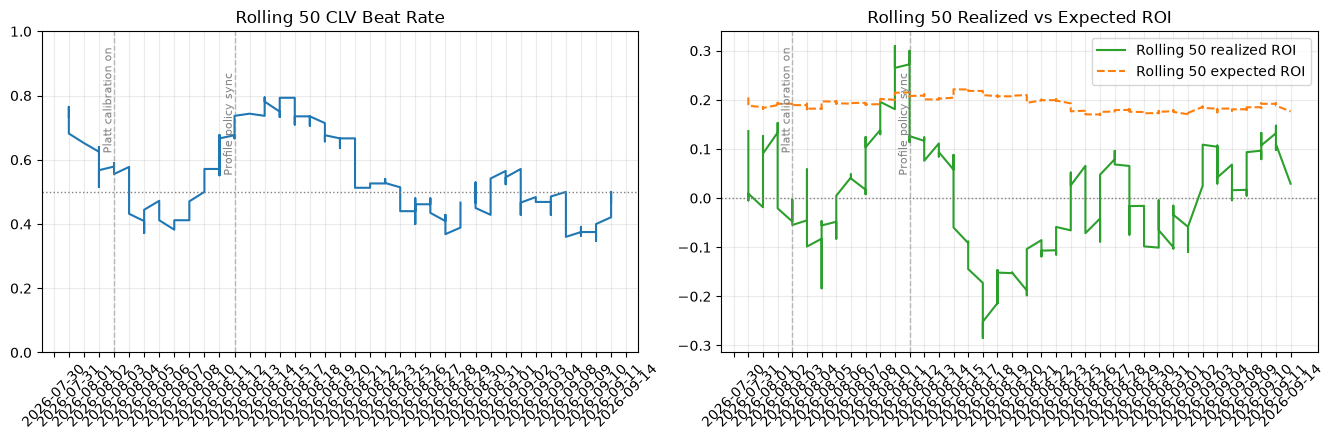

stake-weighted CLV hit-rate


,metric,value,n_clv
0,unweighted_beat_clv_rate,0.540,202
1,stake_weighted_beat_clv_rate,0.537,202



CLV data availability


,n_total_bets,n_clv_available,pct_clv_available
0,340,202,0.594



close_status distribution


,close_status,n,pct
0,ok,160,0.471
1,unavailable,121,0.356
2,ok_cross_book,38,0.112
3,missing,18,0.053
4,ok_live_fallback,3,0.009



side-specific rolling diagnostics (30-bet window)


C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_19100\1196361210.py:115: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("clv_beat").rolling_mean(window_size=30, min_periods=10).alias("roll30_beat_clv"),
C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_19100\1196361210.py:116: DeprecationWarning: the argument `min_periods` for `Expr.rolling_sum` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("pnl").cast(pl.Float64).rolling_sum(window_size=30, min_periods=10).alias("roll30_pnl"),
C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_19100\1196361210.py:117: DeprecationWarning: the argument `min_periods` for `Expr.rolling_sum` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("stake").cast(pl.Float64).rolling_sum(window_size=30, min_periods=10).alias("roll30_stake"),
C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_19100\1196361210.py:118: Dep

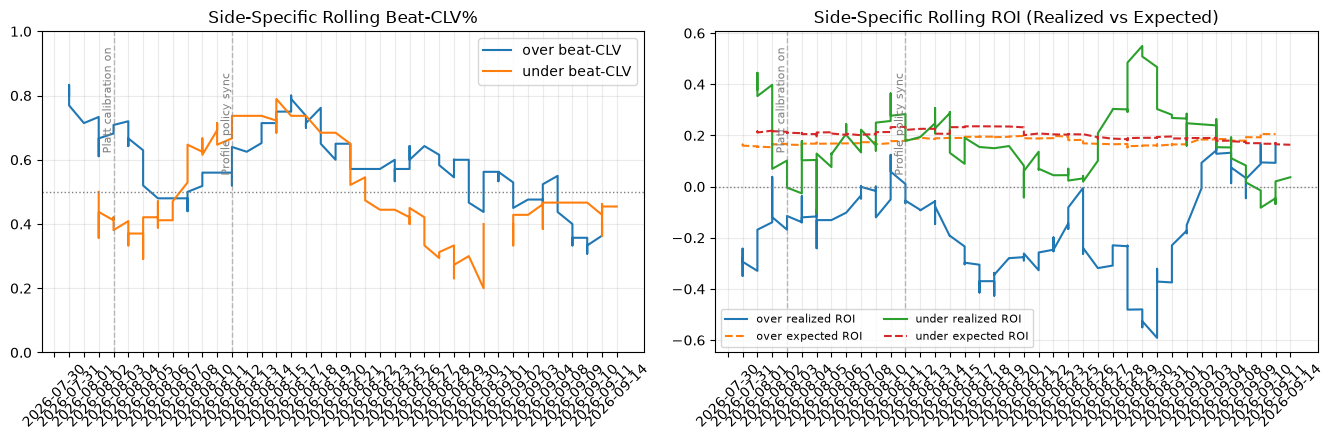


outcome mix for settled BETs (hook = LOSS where |settle_value - line| == 0.5)


,scope,outcome_bucket,n,pct
0,all,hook,56,0.165
1,all,loss,116,0.341
2,all,win,168,0.494
3,over,hook,35,0.192
4,over,loss,70,0.385
5,over,win,77,0.423
6,under,hook,21,0.133
7,under,loss,46,0.291
8,under,win,91,0.576


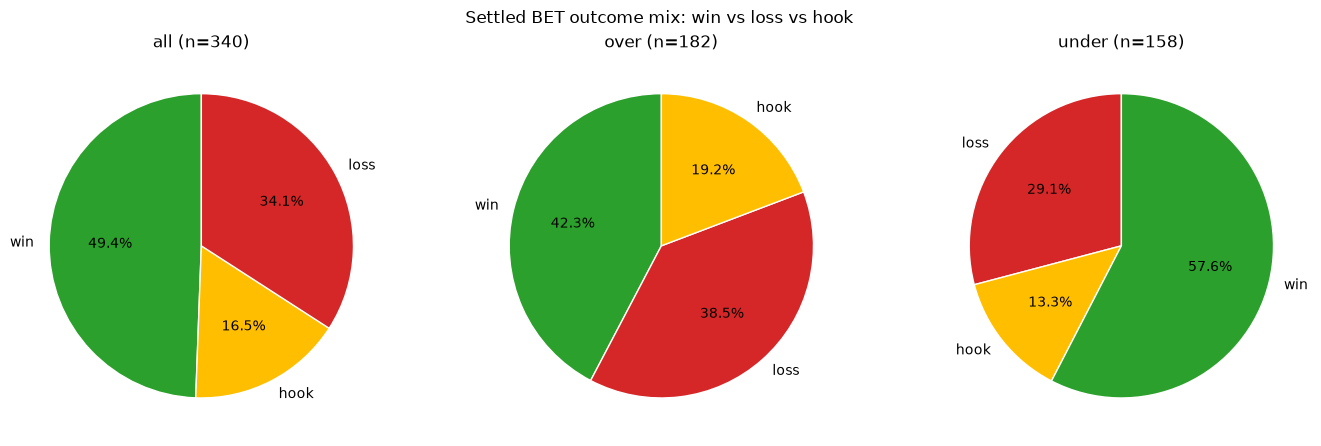


hook impact bridge (counterfactual: hook losses -> push)

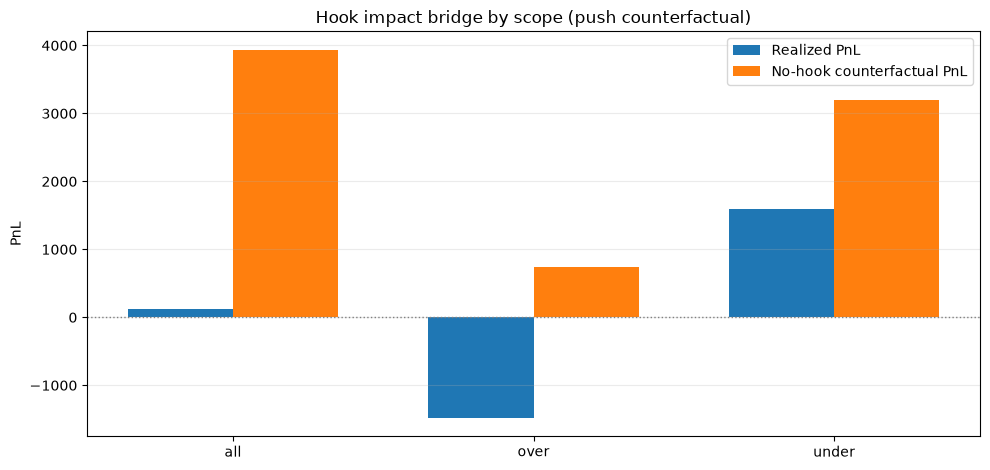


side x edge-bucket ROI gap (realized - expected)


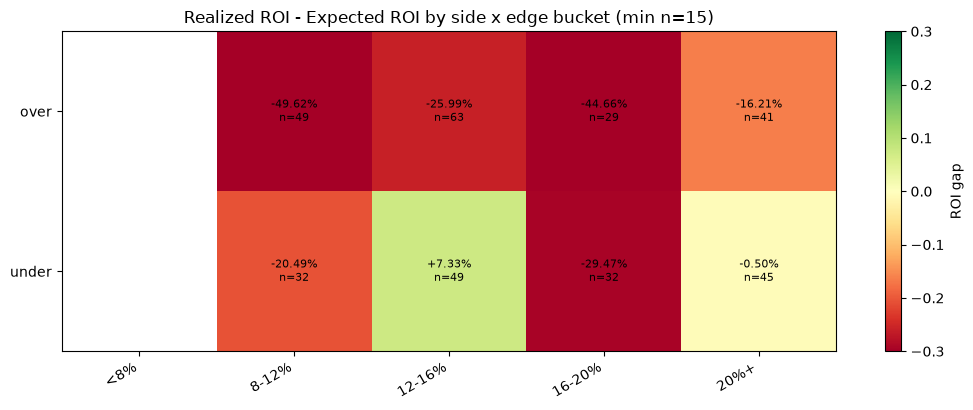


over-side guardrail strip (latest rolling read)


,game_date,roll30_beat_clv,roll30_roi,roll30_expected_roi,roll30_roi_gap
0,2026-09-11,0.4,0.167,0.205,-0.038


guardrails: beat_clv>=0.50 -> WARN; roi_gap>=-0.02 -> WARN

rolling hook-loss rate (30-bet window)


C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_19100\1196361210.py:354: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("hook_loss_flag").rolling_mean(window_size=30, min_periods=10).alias("roll30_hook_loss_rate")


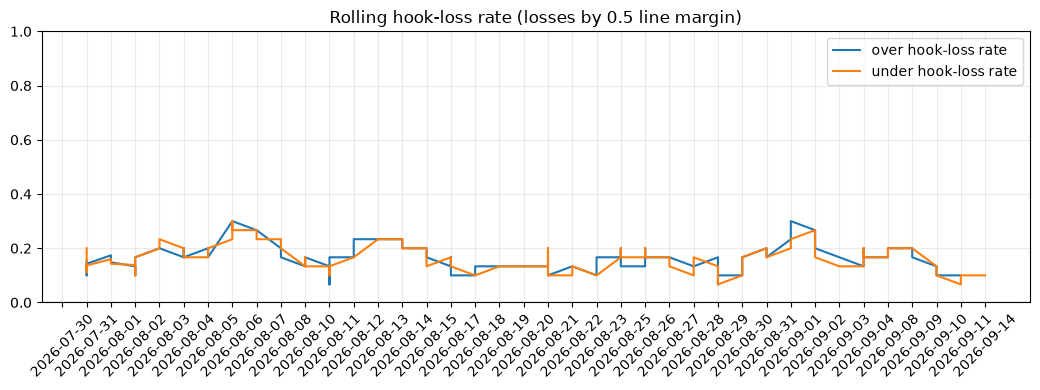

In [5]:
# Standardized weekly diagnostics panel
if settled.is_empty():
    print("No settled rows available for advanced diagnostics.")
else:
    # 1) Rolling 50-bet panel
    sort_cols = [c for c in ["logged_at_utc", "closed_at_utc", "game_date"] if c in settled.columns]
    ordered = settled.sort(sort_cols) if sort_cols else settled
    roll = (
        ordered.with_columns(
            [
                (pl.col("clv_pp") > 0).cast(pl.Float64).alias("clv_beat"),
                (pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).alias("expected_pnl_row"),
            ]
        )
        .with_columns(
            [
                pl.col("clv_beat").rolling_mean(window_size=50, min_periods=15).alias("roll50_beat_clv"),
                pl.col("pnl").cast(pl.Float64).rolling_sum(window_size=50, min_periods=15).alias("roll50_pnl"),
                pl.col("stake").cast(pl.Float64).rolling_sum(window_size=50, min_periods=15).alias("roll50_stake"),
                pl.col("expected_pnl_row").rolling_sum(window_size=50, min_periods=15).alias("roll50_expected_pnl"),
            ]
        )
        .with_columns(
            [
                (pl.col("roll50_pnl") / pl.col("roll50_stake")).alias("roll50_roi"),
                (pl.col("roll50_expected_pnl") / pl.col("roll50_stake")).alias("roll50_expected_roi"),
            ]
        )
        .select([c for c in ["game_date", "roll50_beat_clv", "roll50_roi", "roll50_expected_roi"] if c in ordered.columns or c.startswith("roll50_")])
    )

    print("rolling 50-bet stability panel")

    roll_pdf = roll.to_pandas()
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
    axes[0].plot(roll_pdf["game_date"], roll_pdf["roll50_beat_clv"], label="Rolling 50 beat-CLV%", color="#1f77b4")
    axes[0].axhline(0.5, color="gray", linestyle=":", linewidth=1)
    axes[0].set_title("Rolling 50 CLV Beat Rate")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(alpha=0.25)
    add_process_lines(axes[0])

    axes[1].plot(roll_pdf["game_date"], roll_pdf["roll50_roi"], label="Rolling 50 realized ROI", color="#2ca02c")
    axes[1].plot(roll_pdf["game_date"], roll_pdf["roll50_expected_roi"], label="Rolling 50 expected ROI", color="#ff7f0e", linestyle="--")
    axes[1].axhline(0.0, color="gray", linestyle=":", linewidth=1)
    axes[1].set_title("Rolling 50 Realized vs Expected ROI")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    add_process_lines(axes[1])
    plt.tight_layout()
    plt.show()

    # 2) Stake-weighted CLV hit-rate and data quality
    clv_rows = settled.filter(pl.col("clv_pp").is_not_null())
    if clv_rows.is_empty():
        print("No CLV-tagged rows for stake-weighted and quality views.")
    else:
        unweighted = float((clv_rows["clv_pp"] > 0).mean())
        weighted = float(
            clv_rows.with_columns(
                (pl.when(pl.col("clv_pp") > 0).then(pl.col("stake")).otherwise(pl.lit(0.0))).alias("win_stake")
            )["win_stake"].sum() / clv_rows["stake"].sum()
        )
        sw = pl.DataFrame([
            {
                "metric": "unweighted_beat_clv_rate",
                "value": unweighted,
                "n_clv": clv_rows.height,
            },
            {
                "metric": "stake_weighted_beat_clv_rate",
                "value": weighted,
                "n_clv": clv_rows.height,
            },
        ])
        print("stake-weighted CLV hit-rate")
        show_table(sw)

        quality = settled.select([
            pl.len().alias("n_total_bets"),
            pl.col("clv_pp").drop_nulls().len().alias("n_clv_available"),
            (pl.col("clv_pp").drop_nulls().len() / pl.len()).alias("pct_clv_available"),
        ])
        print("\nCLV data availability")
        show_table(quality)

        if "close_status" in settled.columns:
            print("\nclose_status distribution")
            close_dist = (
                settled.with_columns(pl.col("close_status").fill_null("missing").alias("close_status"))
                .group_by("close_status")
                .agg(pl.len().alias("n"))
                .with_columns((pl.col("n") / pl.col("n").sum()).alias("pct"))
                .sort("n", descending=True)
            )
            show_table(close_dist)

    # 3) Side-specific rolling diagnostics
    side_rows = []
    for side in ["over", "under"]:
        s = ordered.filter(pl.col("side") == side)
        if s.is_empty():
            continue
        s = (
            s.with_columns(
                [
                    (pl.col("clv_pp") > 0).cast(pl.Float64).alias("clv_beat"),
                    (pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).alias("expected_pnl_row"),
                ]
            )
            .with_columns(
                [
                    pl.col("clv_beat").rolling_mean(window_size=30, min_periods=10).alias("roll30_beat_clv"),
                    pl.col("pnl").cast(pl.Float64).rolling_sum(window_size=30, min_periods=10).alias("roll30_pnl"),
                    pl.col("stake").cast(pl.Float64).rolling_sum(window_size=30, min_periods=10).alias("roll30_stake"),
                    pl.col("expected_pnl_row").rolling_sum(window_size=30, min_periods=10).alias("roll30_expected_pnl"),
                ]
            )
            .with_columns(
                [
                    (pl.col("roll30_pnl") / pl.col("roll30_stake")).alias("roll30_roi"),
                    (pl.col("roll30_expected_pnl") / pl.col("roll30_stake")).alias("roll30_expected_roi"),
                    pl.lit(side).alias("side_lbl"),
                ]
            )
        )
        side_rows.append(s.select(["game_date", "side_lbl", "roll30_beat_clv", "roll30_roi", "roll30_expected_roi"]))

    if side_rows:
        side_roll = pl.concat(side_rows, how="vertical_relaxed")
        print("\nside-specific rolling diagnostics (30-bet window)")

        sr = side_roll.to_pandas()
        fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
        for side in sr["side_lbl"].unique():
            sub = sr[sr["side_lbl"] == side]
            axes[0].plot(sub["game_date"], sub["roll30_beat_clv"], label=f"{side} beat-CLV")
            axes[1].plot(sub["game_date"], sub["roll30_roi"], label=f"{side} realized ROI")
            axes[1].plot(sub["game_date"], sub["roll30_expected_roi"], linestyle="--", label=f"{side} expected ROI")

        axes[0].axhline(0.5, color="gray", linestyle=":", linewidth=1)
        axes[0].set_ylim(0, 1)
        axes[0].set_title("Side-Specific Rolling Beat-CLV%")
        axes[0].tick_params(axis="x", rotation=45)
        axes[0].grid(alpha=0.25)
        axes[0].legend()
        add_process_lines(axes[0])

        axes[1].axhline(0.0, color="gray", linestyle=":", linewidth=1)
        axes[1].set_title("Side-Specific Rolling ROI (Realized vs Expected)")
        axes[1].tick_params(axis="x", rotation=45)
        axes[1].grid(alpha=0.25)
        axes[1].legend(ncol=2, fontsize=8)
        add_process_lines(axes[1])

        plt.tight_layout()
        plt.show()

    # 4) Outcome mix (wins / losses / hooks) for settled BETs
    # Hook definition here is LOSS by exactly 0.5 strikeouts.
    if all(c in settled.columns for c in ["result", "line", "settle_value"]):
        mix_src = settled.with_columns(
            (pl.col("settle_value").cast(pl.Float64) - pl.col("line").cast(pl.Float64)).alias("k_minus_line")
        ).with_columns(
            ((pl.col("result") == "loss") & (pl.col("k_minus_line").abs() == 0.5)).alias("is_hook")
        ).with_columns(
            pl.when(pl.col("is_hook"))
            .then(pl.lit("hook"))
            .when(pl.col("result") == "win")
            .then(pl.lit("win"))
            .otherwise(pl.lit("loss"))
            .alias("outcome_bucket")
        )

        def outcome_mix(df: pl.DataFrame, label: str) -> pl.DataFrame:
            if df.is_empty():
                return pl.DataFrame({"scope": [label], "outcome_bucket": ["none"], "n": [0], "pct": [0.0]})
            out = (
                df.group_by("outcome_bucket")
                .agg(pl.len().alias("n"))
                .with_columns((pl.col("n") / pl.col("n").sum()).alias("pct"))
                .with_columns(pl.lit(label).alias("scope"))
            )
            return out.select(["scope", "outcome_bucket", "n", "pct"])

        overall_mix = outcome_mix(mix_src, "all")
        over_mix = outcome_mix(mix_src.filter(pl.col("side") == "over") if "side" in mix_src.columns else pl.DataFrame(), "over")
        under_mix = outcome_mix(mix_src.filter(pl.col("side") == "under") if "side" in mix_src.columns else pl.DataFrame(), "under")
        mix_table = pl.concat([overall_mix, over_mix, under_mix], how="vertical_relaxed")

        print("\noutcome mix for settled BETs (hook = LOSS where |settle_value - line| == 0.5)")
        show_table(mix_table.sort(["scope", "outcome_bucket"]))

        colors = {"win": "#2ca02c", "loss": "#d62728", "hook": "#ffbf00", "none": "#7f7f7f"}
        scopes = ["all", "over", "under"]
        fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
        for ax, scope in zip(axes, scopes):
            sub = mix_table.filter(pl.col("scope") == scope)
            labels = sub["outcome_bucket"].to_list() if not sub.is_empty() else ["none"]
            vals = sub["n"].to_list() if not sub.is_empty() else [0]
            cols = [colors.get(lbl, "#7f7f7f") for lbl in labels]
            total = sum(vals)
            if total == 0:
                ax.text(0.5, 0.5, "No rows", ha="center", va="center")
                ax.axis("off")
                ax.set_title(f"{scope}: no settled bets")
                continue
            ax.pie(
                vals,
                labels=labels,
                colors=cols,
                autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
                startangle=90,
                wedgeprops={"linewidth": 1, "edgecolor": "white"},
            )
            ax.set_title(f"{scope} (n={total})")
        plt.suptitle("Settled BET outcome mix: win vs loss vs hook")
        plt.tight_layout()
        plt.show()

        # 5) Hook-impact PnL bridge (counterfactual assumes hook losses break-even/push)
        bridge_rows = []
        for scope_name, scope_df in [
            ("all", mix_src),
            ("over", mix_src.filter(pl.col("side") == "over") if "side" in mix_src.columns else pl.DataFrame()),
            ("under", mix_src.filter(pl.col("side") == "under") if "side" in mix_src.columns else pl.DataFrame()),
        ]:
            if scope_df.is_empty():
                continue
            realized_pnl = float(scope_df["pnl"].cast(pl.Float64).sum())
            hook_loss_pnl = float(scope_df.filter(pl.col("is_hook"))["pnl"].cast(pl.Float64).sum()) if scope_df.filter(pl.col("is_hook")).height else 0.0
            no_hook_pnl_push = realized_pnl - hook_loss_pnl
            bridge_rows.append(
                {
                    "scope": scope_name,
                    "realized_pnl": realized_pnl,
                    "hook_loss_pnl": hook_loss_pnl,
                    "no_hook_pnl_push_assumption": no_hook_pnl_push,
                }
            )

        if bridge_rows:
            bridge = pl.DataFrame(bridge_rows)
            print("\nhook impact bridge (counterfactual: hook losses -> push)")
            print("WARNING: Counterfactual only. Keep official win-rate/ROI/CLV metrics on realized outcomes where hooks remain losses.")

            bpdf = bridge.to_pandas()
            x = range(len(bpdf))
            width = 0.35
            fig, ax = plt.subplots(figsize=(10, 4.8))
            ax.bar([i - width / 2 for i in x], bpdf["realized_pnl"], width=width, label="Realized PnL", color="#1f77b4")
            ax.bar([i + width / 2 for i in x], bpdf["no_hook_pnl_push_assumption"], width=width, label="No-hook counterfactual PnL", color="#ff7f0e")
            ax.axhline(0, color="gray", linestyle=":", linewidth=1)
            ax.set_xticks(list(x))
            ax.set_xticklabels(bpdf["scope"].tolist())
            ax.set_title("Hook impact bridge by scope (push counterfactual)")
            ax.set_ylabel("PnL")
            ax.legend()
            ax.grid(axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()

        # 6) Side x edge-bucket heatmap: realized ROI - expected ROI
        if all(c in mix_src.columns for c in ["side", "edge", "stake", "pnl"]):
            edge_bucket = (
                pl.when((pl.col("edge") * 100) < 8).then(pl.lit("<8%"))
                .when((pl.col("edge") * 100) < 12).then(pl.lit("8-12%"))
                .when((pl.col("edge") * 100) < 16).then(pl.lit("12-16%"))
                .when((pl.col("edge") * 100) < 20).then(pl.lit("16-20%"))
                .otherwise(pl.lit("20%+"))
                .alias("edge_bucket")
            )
            bucket_order = ["<8%", "8-12%", "12-16%", "16-20%", "20%+"]
            heat = (
                mix_src.with_columns(edge_bucket)
                .group_by(["side", "edge_bucket"])
                .agg(
                    pl.len().alias("n"),
                    pl.col("stake").cast(pl.Float64).sum().alias("stake"),
                    pl.col("pnl").cast(pl.Float64).sum().alias("realized_pnl"),
                    (pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum().alias("expected_pnl"),
                )
                .with_columns(
                    (pl.col("realized_pnl") / pl.col("stake")).alias("realized_roi"),
                    (pl.col("expected_pnl") / pl.col("stake")).alias("expected_roi"),
                )
                .with_columns((pl.col("realized_roi") - pl.col("expected_roi")).alias("roi_gap"))
                .with_columns(pl.col("edge_bucket").cast(pl.Enum(bucket_order)))
                .sort(["side", "edge_bucket"])
            )

            print("\nside x edge-bucket ROI gap (realized - expected)")

            hpdf = heat.select(["side", "edge_bucket", "roi_gap", "n"]).to_pandas()
            if not hpdf.empty:
                pivot = hpdf.pivot(index="side", columns="edge_bucket", values="roi_gap").reindex(columns=bucket_order)
                n_pivot = hpdf.pivot(index="side", columns="edge_bucket", values="n").reindex(columns=bucket_order)
                HEATMAP_MIN_N = 15

                fig, ax = plt.subplots(figsize=(10.5, 4.2))
                im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=-0.30, vmax=0.30)
                ax.set_xticks(range(len(pivot.columns)))
                ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
                ax.set_yticks(range(len(pivot.index)))
                ax.set_yticklabels(pivot.index)
                ax.set_title(f"Realized ROI - Expected ROI by side x edge bucket (min n={HEATMAP_MIN_N})")

                for i, side_name in enumerate(pivot.index):
                    for j, edge_name in enumerate(pivot.columns):
                        v = pivot.iloc[i, j]
                        n_cell = n_pivot.iloc[i, j] if (i < len(n_pivot.index) and j < len(n_pivot.columns)) else None
                        if n_cell == n_cell and int(n_cell) < HEATMAP_MIN_N:
                            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="lightgray", alpha=0.6))
                            ax.text(j, i, f"n={int(n_cell)}", ha="center", va="center", fontsize=8, color="black")
                        elif v == v:
                            ax.text(j, i, f"{v:+.2%}\nn={int(n_cell)}", ha="center", va="center", fontsize=8)

                fig.colorbar(im, ax=ax, label="ROI gap")
                plt.tight_layout()
                plt.show()

        # 7) Over-side guardrail strip (quick go/no-go diagnostics)
        over_guardrail = pl.DataFrame()
        if side_rows:
            over_roll = side_roll.filter(pl.col("side_lbl") == "over").sort("game_date")
            if not over_roll.is_empty():
                latest_over = over_roll.tail(1)
                over_guardrail = latest_over.select(
                    [
                        pl.col("game_date"),
                        pl.col("roll30_beat_clv"),
                        pl.col("roll30_roi"),
                        pl.col("roll30_expected_roi"),
                        (pl.col("roll30_roi") - pl.col("roll30_expected_roi")).alias("roll30_roi_gap"),
                    ]
                )
                print("\nover-side guardrail strip (latest rolling read)")
                show_table(over_guardrail)
                if over_guardrail.height:
                    b = float(over_guardrail["roll30_beat_clv"][0]) if over_guardrail["roll30_beat_clv"][0] is not None else None
                    g = float(over_guardrail["roll30_roi_gap"][0]) if over_guardrail["roll30_roi_gap"][0] is not None else None
                    beat_flag = "PASS" if (b is not None and b >= 0.5) else "WARN"
                    gap_flag = "PASS" if (g is not None and g >= -0.02) else "WARN"
                    print(f"guardrails: beat_clv>=0.50 -> {beat_flag}; roi_gap>=-0.02 -> {gap_flag}")

        # 8) Rolling hook-loss rate trend (loss hooks only)
        if all(c in mix_src.columns for c in ["game_date", "is_hook"]):
            hook_src = mix_src.sort([c for c in ["logged_at_utc", "closed_at_utc", "game_date"] if c in mix_src.columns])
            hook_roll = (
                hook_src.with_columns(pl.col("is_hook").cast(pl.Float64).alias("hook_loss_flag"))
                .with_columns(
                    pl.col("hook_loss_flag").rolling_mean(window_size=30, min_periods=10).alias("roll30_hook_loss_rate")
                )
                .select([c for c in ["game_date", "side", "roll30_hook_loss_rate"] if c in hook_src.columns or c == "roll30_hook_loss_rate"])
            )
            if not hook_roll.is_empty():
                print("\nrolling hook-loss rate (30-bet window)")
                hp = hook_roll.to_pandas()
                fig, ax = plt.subplots(figsize=(10.5, 4.0))
                if "side" in hp.columns:
                    for side in [s for s in hp["side"].dropna().unique().tolist()]:
                        sub = hp[hp["side"] == side]
                        ax.plot(sub["game_date"], sub["roll30_hook_loss_rate"], label=f"{side} hook-loss rate")
                else:
                    ax.plot(hp["game_date"], hp["roll30_hook_loss_rate"], label="hook-loss rate")
                ax.axhline(0.0, color="gray", linestyle=":", linewidth=1)
                ax.set_ylim(0, 1)
                ax.set_title("Rolling hook-loss rate (losses by 0.5 line margin)")
                ax.tick_params(axis="x", rotation=45)
                ax.grid(alpha=0.25)
                ax.legend()
                plt.tight_layout()
                plt.show()